# Exploratory Data Analysis (EDA) — Medical Insurance Claim Fraud Detection
**Institution:** Indian Institute of Information Technology (IIIT), Dharwad  
**Department:** B.Tech Data Science and Artificial Intelligence  
**Faculty Adviser:** Prof. Ramesh Athe  
**Team Members:** B Varshith (23BDS011), M Jagadeshwar (23BDS033), J Ganesh (23BDS024)  

--- 

## 1. Introduction and Objectives
This interactive notebook performs an in-depth Exploratory Data Analysis (EDA) on the medical insurance claim dataset (`4,500 claims`). It explores distributions, fraud rates across Indian States and Cities, Hospital Tier cost disparities, and numeric correlations.

In [1]:
import os, sys
if '..' not in sys.path:
    sys.path.insert(0, '..')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loading import execute_data_loading_pipeline

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load and enrich dataset with Indian domain context
df = execute_data_loading_pipeline('data/raw/Health Insurance Fraud Claims.xlsx')
print('Dataset Shape:', df.shape)
df.head(3)

[2026-08-07 15:42:54] [INFO] [DataLoadingLogger]: Executing Complete Data Loading and Domain Enrichment Pipeline...


[2026-08-07 15:42:54] [INFO] [DataLoadingLogger]: Loading raw insurance dataset from: data/raw/Health Insurance Fraud Claims.xlsx


[2026-08-07 15:42:55] [INFO] [DataLoadingLogger]: Successfully loaded dataset with shape: 4500 rows, 19 columns


[2026-08-07 15:42:55] [INFO] [DataLoadingLogger]: Enriching dataset with Indian healthcare and insurance domain context...


[2026-08-07 15:42:55] [INFO] [DataLoadingLogger]: Indian context enrichment complete. Total records: 4500, Fraud rate: 6.00%


...

[2026-08-07 15:42:56] [INFO] [DataLoadingLogger]: Generating synthetic Indian health insurance claim dataset (1500 records)...


[2026-08-07 15:42:56] [INFO] [DataLoadingLogger]: Synthetic Indian claim dataset saved at: data/synthetic/synthetic_indian_claims.csv


[2026-08-07 15:42:56] [INFO] [DataLoadingLogger]: Enriched dataset checkpoint saved at: data/processed/claims_enriched.csv


Dataset Shape: (4500, 27)


,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,...,Cluster,ClaimLegitimacy,IndianState,IndianCity,PolicyType,InsurerCompany,HospitalTier,ClaimAmountINR,PatientIncomeINR,IsFraud
0,4d76c7f7-d36a-4139-b451-a9a4ad10d7d5,19cf2638-3ec0-4ed9-9995-d9ba4553813a,a3d0cc80-dffe-40ff-a302-23c8ffeedb36,7820.52,2024-07-08,Ta150,iO013,96,F,Orthopedics,...,3,Legitimate,Madhya Pradesh,Indore,Employer Group Health Insurance,United India Insurance,Tier-1 Metro Corporate Hospital,195513.0,1439877.75,0
1,e35193b4-3609-492b-866a-98de19317e9c,5c4bb6c5-4dd3-4a86-85fa-f36c0d8debff,a9f25acf-92b8-45e2-9cef-87bd07d0a591,5453.86,2024-07-08,Fo766,jR349,95,M,Cardiology,...,2,Legitimate,Delhi NCT,New Delhi,Individual Health Plan,United India Insurance,Tier-2 City Multi-Specialty Hospital,136346.5,3519318.00,0
2,1f3fa373-25ed-4ff4-b6c7-38dcb2fb297f,777866e0-4d10-45a8-a7b4-dbdaa26d5a81,951b1e08-9948-4956-80e5-9277f16bd290,8229.86,2024-07-08,AX876,uU479,10,M,Cardiology,...,3,Legitimate,Gujarat,Ahmedabad,Senior Citizen Red Carpet Plan,ICICI Lombard General Insurance,Tier-2 City Multi-Specialty Hospital,205746.5,1745079.75,0


## 2. Summary Statistics & Class Imbalance Analysis
Medical insurance fraud datasets typically exhibit strong class imbalance. Let's inspect the exact proportion of **Legitimate** vs. **Fraudulent** claims in the Indian healthcare dataset.

                 Count  Percentage (%)
ClaimLegitimacy                       
Legitimate        4230            94.0
Fraud              270             6.0


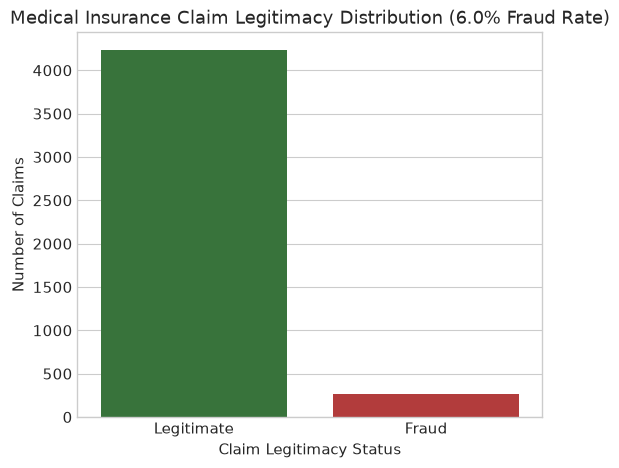

In [2]:
# Target variable distribution
fraud_counts = df['ClaimLegitimacy'].value_counts()
fraud_pct = df['ClaimLegitimacy'].value_counts(normalize=True) * 100
summary_df = pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct})
print(summary_df)

# Plot Class Distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='ClaimLegitimacy', hue='ClaimLegitimacy', palette=['#2e7d32', '#c62828'], legend=False)
plt.title('Medical Insurance Claim Legitimacy Distribution (6.0% Fraud Rate)')
plt.xlabel('Claim Legitimacy Status')
plt.ylabel('Number of Claims')
plt.show()

## 3. Indian Healthcare Provider Tier & Cost Analysis (INR)
In India, hospital pricing varies significantly across provider tiers:
- **Tier-1 Metro Corporate Hospital:** Premium multi-specialty hospitals in metro cities (Mumbai, Bengaluru, Hyderabad, Delhi).
- **Tier-2 City Multi-Specialty Hospital:** Standard accredited city hospitals.
- **Tier-3 Town Nursing Home:** Smaller town nursing homes.

A major fraud indicator is a **Tier-3 Nursing Home billing Tier-1 corporate rates**.

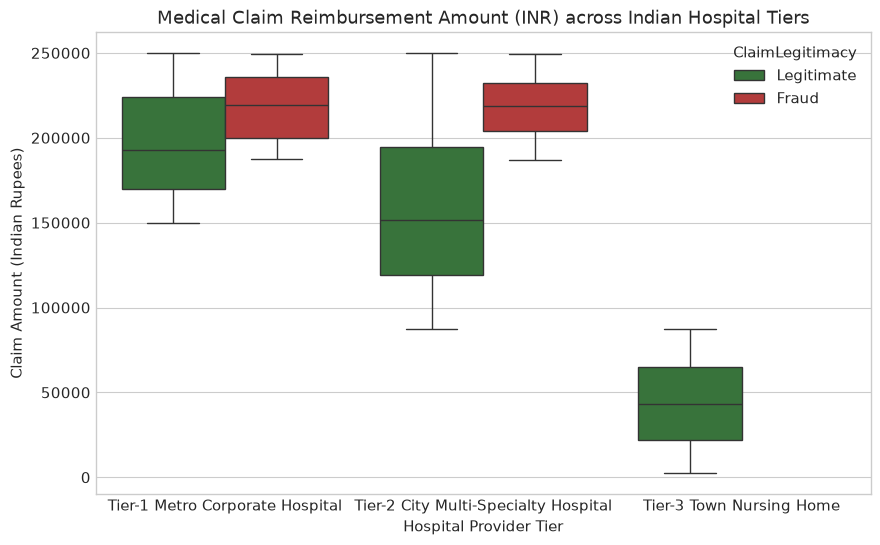

ClaimLegitimacy,Fraud,Legitimate
HospitalTier,,
Tier-1 Metro Corporate Hospital,219296.995690,196443.526210
Tier-2 City Multi-Specialty Hospital,218077.069575,157964.363380
Tier-3 Town Nursing Home,NaN,43981.628695


In [3]:
# Claim Amount INR across Hospital Tiers
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='HospitalTier', y='ClaimAmountINR', hue='ClaimLegitimacy',
    palette=['#2e7d32', '#c62828']
)
plt.title('Medical Claim Reimbursement Amount (INR) across Indian Hospital Tiers')
plt.xlabel('Hospital Provider Tier')
plt.ylabel('Claim Amount (Indian Rupees)')
plt.show()

# Table of Mean Claim Amount INR by Tier and Legitimacy
df.groupby(['HospitalTier', 'ClaimLegitimacy'])['ClaimAmountINR'].mean().unstack()

## 4. Geographic Analysis across Indian States
Let's examine the distribution of fraudulent claims across Indian states to identify regional patterns.

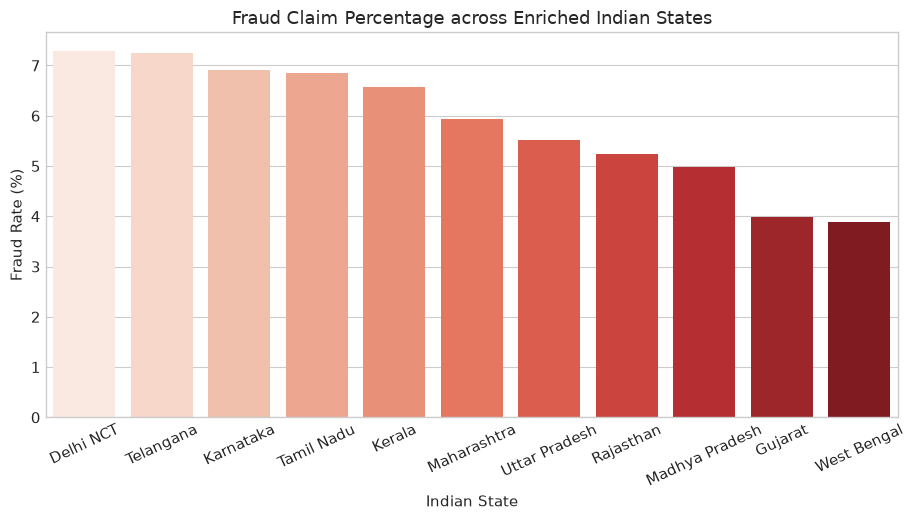

In [4]:
state_fraud = df.groupby('IndianState')['IsFraud'].mean().reset_index()
state_fraud['Fraud_Percentage'] = state_fraud['IsFraud'] * 100
state_fraud = state_fraud.sort_values('Fraud_Percentage', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=state_fraud, x='IndianState', y='Fraud_Percentage', hue='IndianState', palette='Reds', legend=False)
plt.title('Fraud Claim Percentage across Enriched Indian States')
plt.xlabel('Indian State')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=25)
plt.show()

## 5. Correlation Analysis of Numeric Attributes
Let's visualize the pairwise Pearson correlation matrix across numeric features.

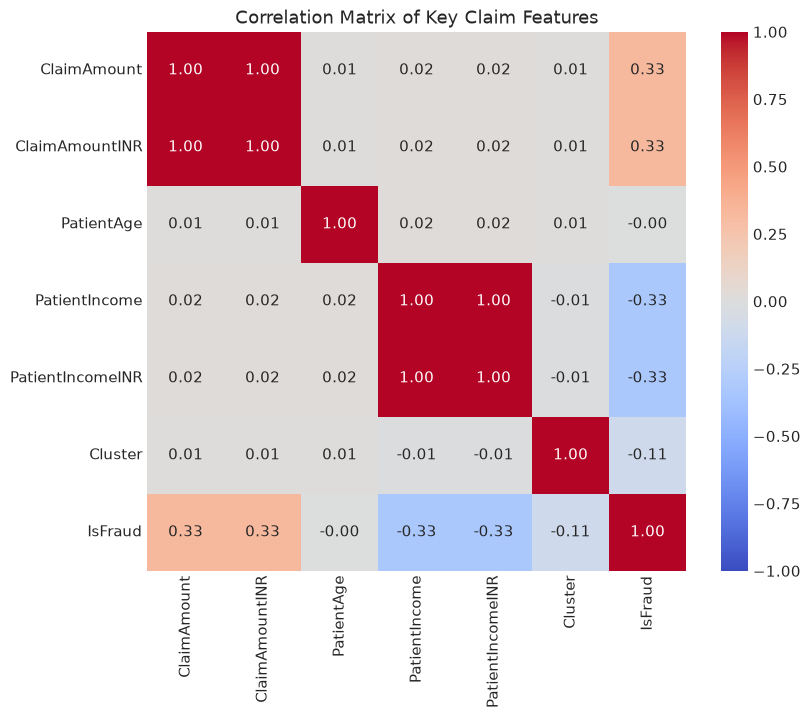

In [5]:
num_cols = ['ClaimAmount', 'ClaimAmountINR', 'PatientAge', 'PatientIncome', 'PatientIncomeINR', 'Cluster', 'IsFraud']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Key Claim Features')
plt.show()

## 6. Conclusion of Exploratory Analysis
The EDA confirms:
1. **Imbalance:** Exactly 6.0% of claims are fraudulent, requiring SMOTE during model training.
2. **Tier Mismatch:** High-value fraudulent claims often appear in lower-tier or non-accredited providers.
3. **Claim Amount:** Billed amounts in INR provide strong discriminative signal when benchmarked against regional specialty norms.